## CUSTOMER SEGMENTATION USING PCA, K-MEANS AND APPLYING CLASSIFICATION ALGORITHM FOR CLASS PREDICTION

### SECTION-1 MODULE AND DATA IMPORTATION

In [1]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
import numpy as np

In [2]:
df = pd.read_csv('Mall_Customers.csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


### SECTION-2 EDA

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [4]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


c:\Users\Tammy\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\Tammy\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\Tammy\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


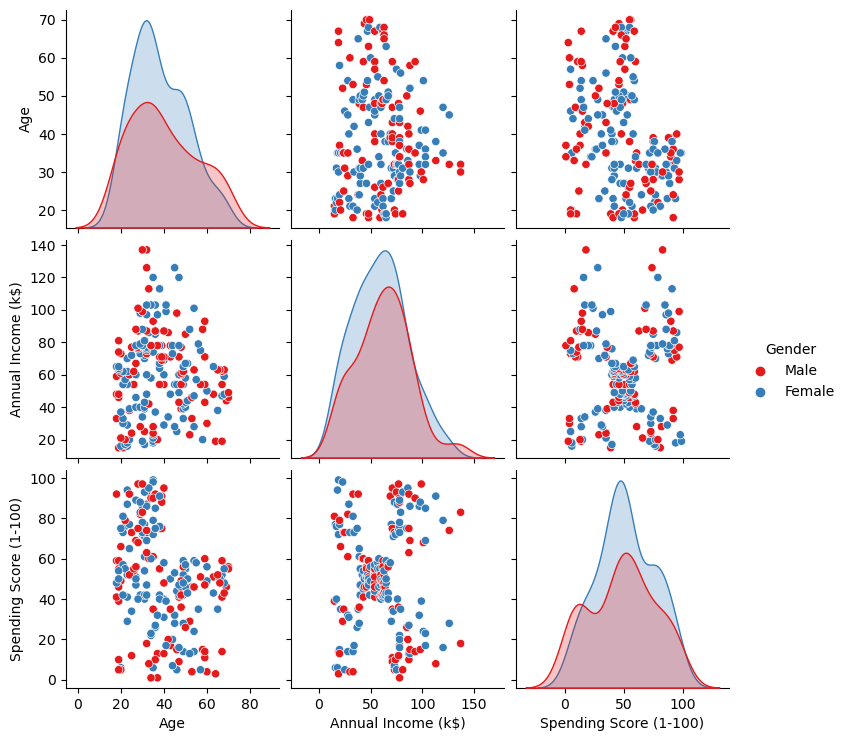

In [5]:
data = df.drop(['CustomerID'], axis=1)
sns.pairplot(data, hue='Gender', palette='Set1')

### It can be seen that a correlation between Annual Income and Spending Score gives different Clusters which is the most distinct plot among all.

<Axes: xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)'>

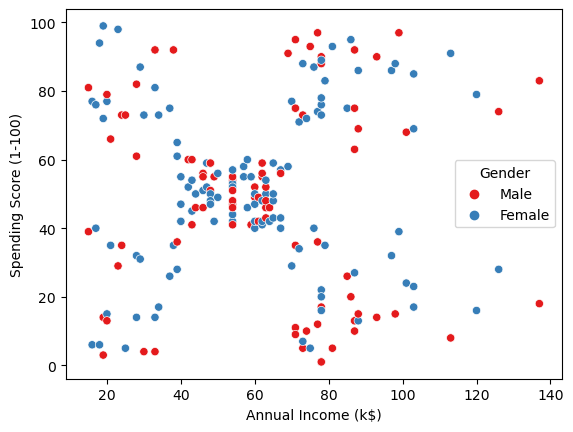

In [6]:
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', data=data, hue='Gender', palette='Set1')

### APPLYING PCA TO UNCOVER PATTERNS TO SEE IF WE CAN MATCH THE PATTERN WITH THE PLOT ABOVE 

### SECTION-3 Feature Selection with PCA

In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [8]:
data.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


### CREATING TWO DIFFERENT FRAME WITH ONE KEEPING THE GENDER COLUMN, WHILE THE SECOND DROPPING THE GENDER COLUMN

In [9]:
# First of, I will create two tables with Gender encoded as 0 and 1, then I will create another table without Gender

# One-hot Encode Gender
df = df.drop(['CustomerID'], axis=1)
df_1 = pd.get_dummies(df, columns=['Gender'], dtype=int)

# Second table without Gender
df_2 = data.drop(['Gender'], axis=1)


In [10]:
# Standardizing df_1
scaler_1 = StandardScaler()
df_1_scale = scaler_1.fit(df_1)
df_1_scaled = df_1_scale.transform(df_1)

print(df_1.head())

print(df_1_scaled[:6])

   Age  Annual Income (k$)  Spending Score (1-100)  Gender_Female  Gender_Male
0   19                  15                      39              0            1
1   21                  15                      81              0            1
2   20                  16                       6              1            0
3   23                  16                      77              1            0
4   31                  17                      40              1            0
[[-1.42456879 -1.73899919 -0.43480148 -1.12815215  1.12815215]
 [-1.28103541 -1.73899919  1.19570407 -1.12815215  1.12815215]
 [-1.3528021  -1.70082976 -1.71591298  0.88640526 -0.88640526]
 [-1.13750203 -1.70082976  1.04041783  0.88640526 -0.88640526]
 [-0.56336851 -1.66266033 -0.39597992  0.88640526 -0.88640526]
 [-1.20926872 -1.66266033  1.00159627  0.88640526 -0.88640526]]


In [12]:
scaler_2 = StandardScaler()
df_2_scaled = scaler_2.fit_transform(df_2)

print(df_2.head())
print(df_2_scaled[:6])

   Age  Annual Income (k$)  Spending Score (1-100)
0   19                  15                      39
1   21                  15                      81
2   20                  16                       6
3   23                  16                      77
4   31                  17                      40
[[-1.42456879 -1.73899919 -0.43480148]
 [-1.28103541 -1.73899919  1.19570407]
 [-1.3528021  -1.70082976 -1.71591298]
 [-1.13750203 -1.70082976  1.04041783]
 [-0.56336851 -1.66266033 -0.39597992]
 [-1.20926872 -1.66266033  1.00159627]]


In [13]:
# Applying PCA to both

pca_1 = PCA(n_components=len(df_1.columns))
pca_2 = PCA(n_components=len(df_2.columns))

df_1_pca = pca_1.fit(df_1_scaled)
df_2_pca = pca_2.fit(df_2_scaled)

pcas = [df_1_pca, df_2_pca]

for pca in pcas:
    explained  = pca.explained_variance_ratio_
    cumulative = np.cumsum(explained)

    print('=== 📊 EXPLAINED VARIANCE PER COMPONENT ===')

    for i, (e, c) in enumerate(zip(explained, cumulative), 1):
       bar = '█' * int(e * 100)
       print(f'   PC{i}: {e*100:>5.1f}% (cumulative {c*100:>5.1f}%) {bar}')


=== 📊 EXPLAINED VARIANCE PER COMPONENT ===
   PC1:  40.5% (cumulative  40.5%) ████████████████████████████████████████
   PC2:  26.2% (cumulative  66.7%) ██████████████████████████
   PC3:  19.8% (cumulative  86.5%) ███████████████████
   PC4:  13.5% (cumulative 100.0%) █████████████
   PC5:   0.0% (cumulative 100.0%) 
=== 📊 EXPLAINED VARIANCE PER COMPONENT ===
   PC1:  44.3% (cumulative  44.3%) ████████████████████████████████████████████
   PC2:  33.3% (cumulative  77.6%) █████████████████████████████████
   PC3:  22.4% (cumulative 100.0%) ██████████████████████


In [57]:
loadings = pd.DataFrame(
    pca_2.components_.T,
    columns=['PC1', 'PC2', 'PC3'],   # adjust if you used more/less PCs
    index=df_2.columns               # original feature names
)

print('=== 🧮 COMPONENT LOADINGS ===')
print('(How much each original feature contributes to each component)\n')
print(loadings.round(3))


=== 🧮 COMPONENT LOADINGS ===
(How much each original feature contributes to each component)

                          PC1    PC2    PC3
Age                     0.706  0.030  0.707
Annual Income (k$)     -0.048  0.999  0.005
Spending Score (1-100) -0.706 -0.038  0.707


c:\Users\Tammy\anaconda3\Lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  func(*args, **kwargs)
c:\Users\Tammy\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


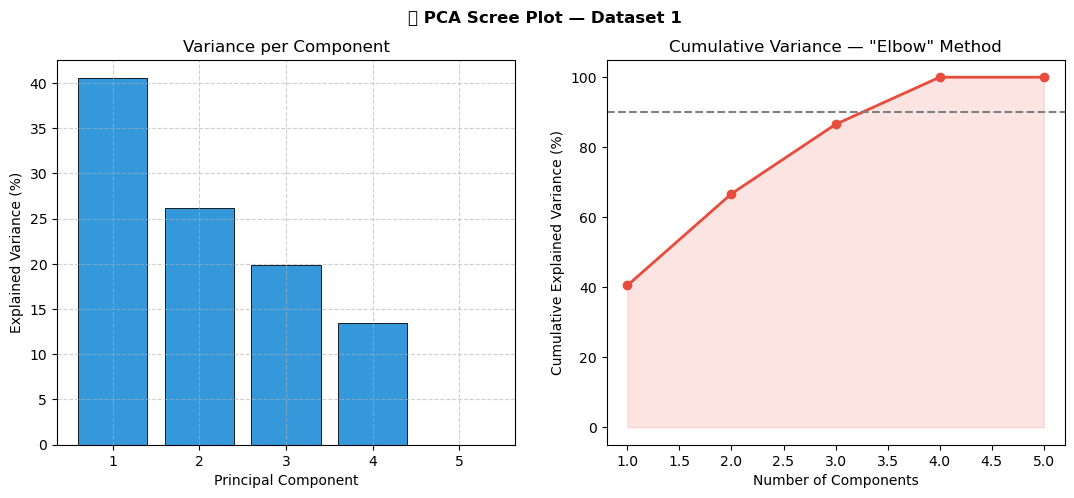

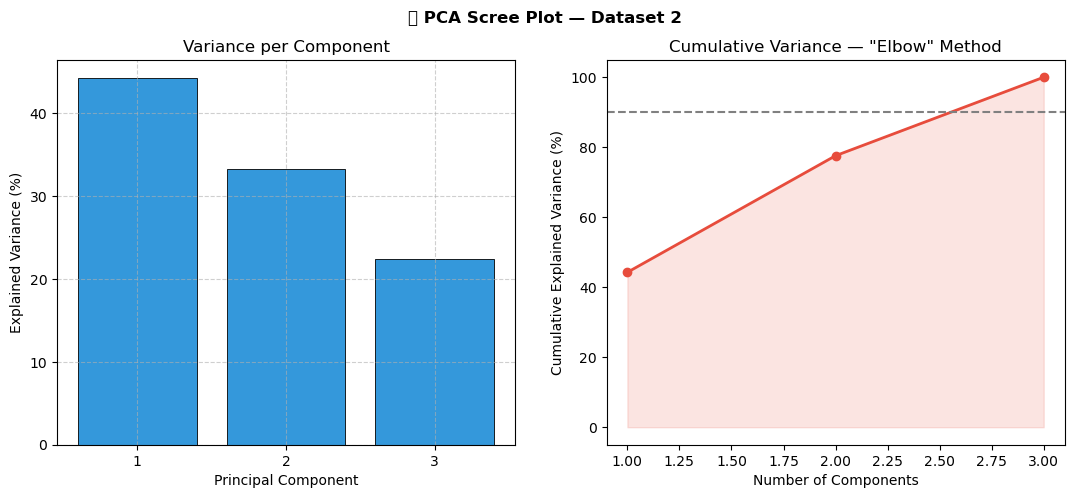

In [14]:
pcas = [df_1_pca, df_2_pca]   # your PCA objects
titles = ["Dataset 1", "Dataset 2"]

for idx, pca in enumerate(pcas, 1):
    explained  = pca.explained_variance_ratio_
    cumulative = np.cumsum(explained)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(f'📊 PCA Scree Plot — {titles[idx-1]}', fontsize=12, fontweight='bold')

    # Bar plot: variance per component
    axes[0].bar(range(1, len(explained)+1), explained*100,
                color='#3498db', edgecolor='black', linewidth=0.6)
    axes[0].set_xlabel('Principal Component')
    axes[0].set_ylabel('Explained Variance (%)')
    axes[0].set_title('Variance per Component')
    axes[0].set_xticks(range(1, len(explained)+1))
    axes[0].grid(True, linestyle='--', alpha=0.6)   # add grid

    # Line plot: cumulative variance
    axes[1].plot(range(1, len(cumulative)+1), cumulative*100,
                 marker='o', color='#e74c3c', linewidth=2)
    axes[1].axhline(90, color='gray', linestyle='--', label='90% threshold')
    axes[1].fill_between(range(1, len(cumulative)+1), cumulative*100, alpha=0.15, color='#e74c3c')
    axes[1].set_xlabel('Number of Components')
    axes[1].set_ylabel('Cumulative Explained Variance (%)')
    axes[1].set_title('Cumulative Variance — "Elbow" Method')

### VISUALIZING SCATTER PLOT OF PCAs

C:\Users\Tammy\AppData\Local\Temp\ipykernel_37564\1619899058.py:19: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  plt.tight_layout()
c:\Users\Tammy\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


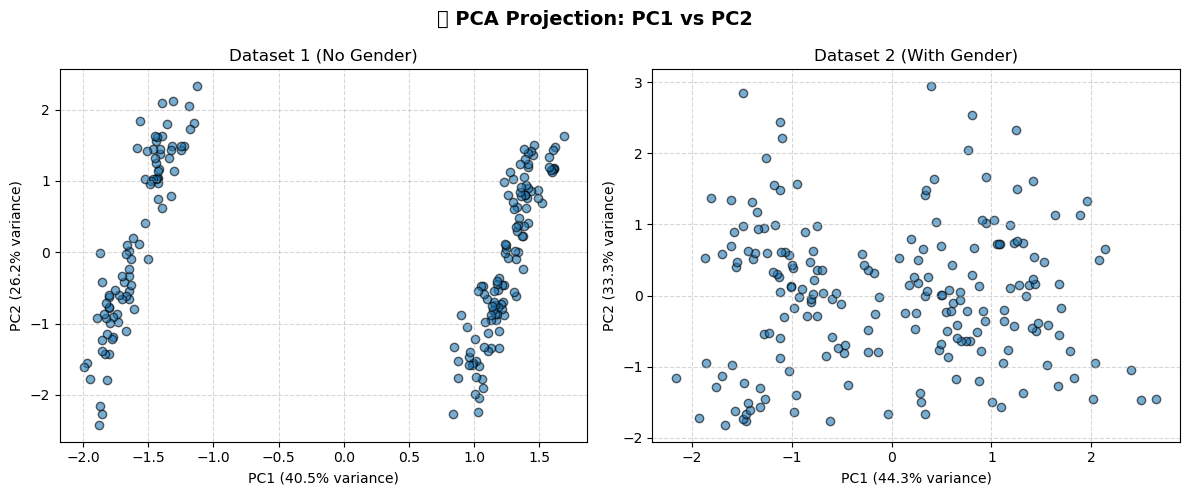

In [15]:
datasets = [df_1_scaled, df_2_scaled]   # scaled arrays
titles   = ["Dataset 1 (No Gender)", "Dataset 2 (With Gender)"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for idx, (X_scaled, title) in enumerate(zip(datasets, titles)):
    # Fit PCA with 2 components
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)

    # Scatter plot PC1 vs PC2
    axes[idx].scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.6, edgecolor='k')
    axes[idx].set_title(title)
    axes[idx].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
    axes[idx].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
    axes[idx].grid(True, linestyle='--', alpha=0.5)

plt.suptitle("📊 PCA Projection: PC1 vs PC2", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### APPLYING K-MEANS CLUSTERING TO PCA COMPONENTS FROM DATASET-2 TO DETERMINE CLUSTERS FOR SEGMENTING CUSTOMERS

### APPLYING ELBOW METHOD FOR SELECTING OPTIMAL K

In [ ]:
from sklearn.cluster import KMeans

K_RANGE  = range(1, 11)
datasets = [df_1_scaled, df_2_scaled]
titles   = ["Dataset 1 (No Gender)", "Dataset 2 (With Gender)"]

for idx, X_scaled in enumerate(datasets, 1):
    inertias = []
    print(f"\nElbow method — {titles[idx-1]}")
    print(f"{'k':>4}  {'Inertia':>12}  {'Drop %':>8}")
    print("-" * 30)

    for k in K_RANGE:
        km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)
        km.fit(X_scaled)
        inertias.append(km.inertia_)

        # Calculate drop percentage compared to previous k
        if k > 1:
            drop = (inertias[-2] - inertias[-1]) / inertias[-2] * 100
        else:
            drop = 0

        marker = "  ← elbow" if 4 <= k <= 6 else ""
        print(f"{k:>4}  {inertias[-1]:>12.1f}  {drop:>7.1f}%{marker}")



Elbow method — Dataset 1 (No Gender)
   k       Inertia    Drop %
------------------------------
   1        1000.0      0.0%
   2         597.9     40.2%
   3         488.2     18.4%
   4         386.8     20.8%  ← elbow


c:\Users\Tammy\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Tammy\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Tammy\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Tammy\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Window

   5         331.3     14.4%  ← elbow
   6         280.7     15.3%  ← elbow
   7         239.2     14.8%
   8         199.8     16.5%


c:\Users\Tammy\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Tammy\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Tammy\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Tammy\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Window

   9         174.2     12.8%
  10         152.7     12.3%

Elbow method — Dataset 2 (With Gender)
   k       Inertia    Drop %
------------------------------
   1         600.0      0.0%
   2         389.4     35.1%


...

c:\Users\Tammy\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Tammy\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Tammy\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


   6         133.9     20.4%  ← elbow
   7         117.0     12.6%
   8         103.9     11.2%


c:\Users\Tammy\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Tammy\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Tammy\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


   9          93.1     10.4%
  10          82.4     11.5%


c:\Users\Tammy\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


### APPLYING SILHOUTTE SCORE TO CHECK CLUSTER CLOSENESS

In [18]:
 
#    Silhouette score: how similar each point is to its own cluster vs others
#    Range: -1 (wrong cluster) to +1 (perfect cluster)
#    Peak score confirms the optimal k from the elbow method
from sklearn.metrics import silhouette_score

K_RANGE = range(2, 11)  # silhouette requires at least 2 clusters
datasets = [df_1_scaled, df_2_scaled]
titles   = ["Dataset 1 (No Gender)", "Dataset 2 (With Gender)"]

for idx, X_scaled in enumerate(datasets, 1):
    print(f"\nSilhouette scores — {titles[idx-1]}")
    print(f"{'k':>4}  {'Score':>10}")
    print("-" * 20)

    for k in K_RANGE:
        km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)
        labels = km.fit_predict(X_scaled)
        score = silhouette_score(X_scaled, labels)
        print(f"{k:>4}  {score:>10.3f}")


Silhouette scores — Dataset 1 (No Gender)
   k       Score
--------------------


c:\Users\Tammy\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


   2       0.396
   3       0.368


c:\Users\Tammy\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Tammy\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


   4       0.332
   5       0.346


...

c:\Users\Tammy\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


   7       0.417
   8       0.408


c:\Users\Tammy\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Tammy\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


   9       0.418
  10       0.407


c:\Users\Tammy\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


### Elbow plus Silhoutte Visualization

c:\Users\Tammy\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Tammy\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Tammy\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Tammy\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Window

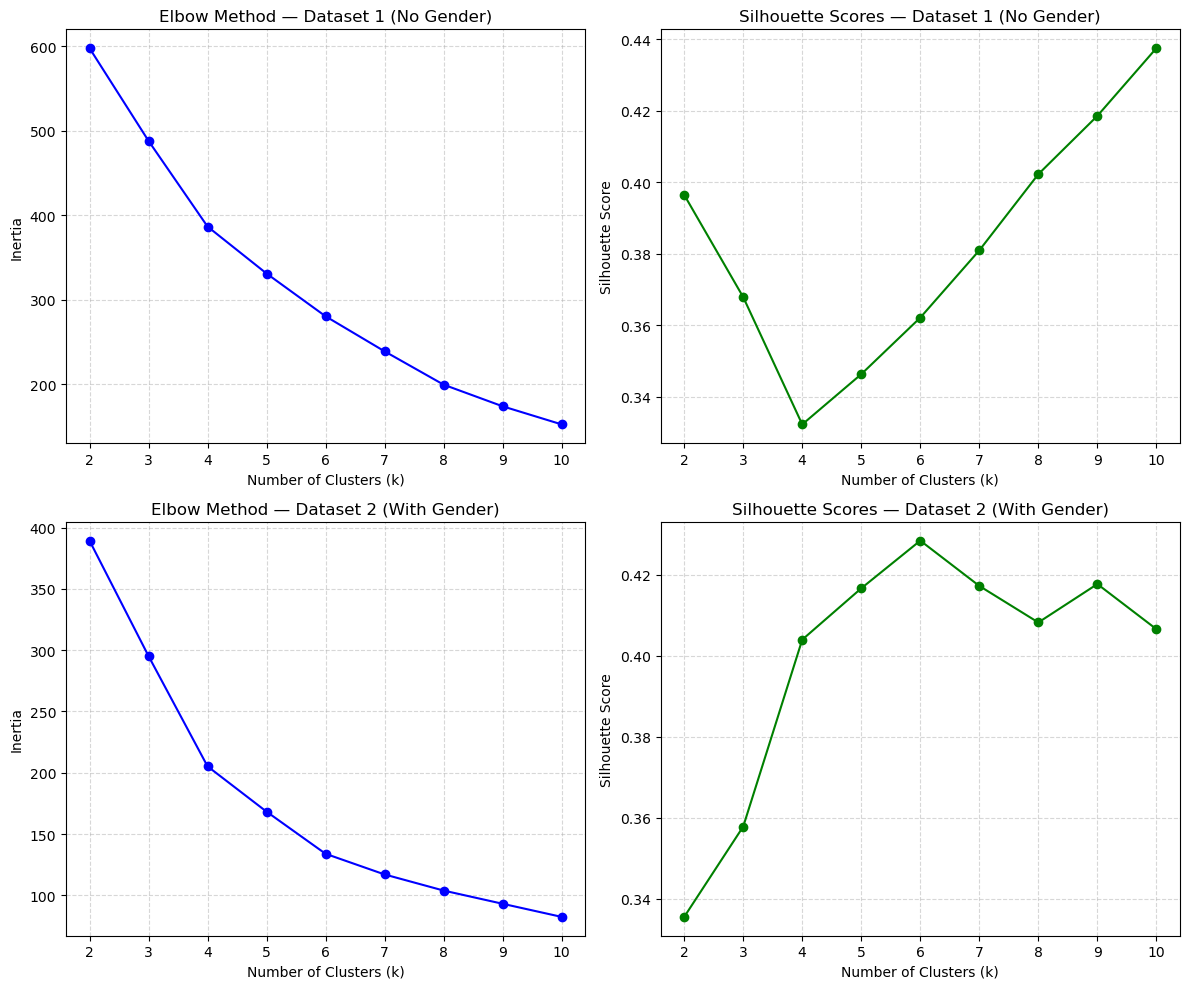

In [19]:
K_RANGE = range(2, 11)  # silhouette requires at least 2 clusters
datasets = [df_1_scaled, df_2_scaled]
titles   = ["Dataset 1 (No Gender)", "Dataset 2 (With Gender)"]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for idx, X_scaled in enumerate(datasets, 1):
    inertias = []
    silhouettes = []

    for k in K_RANGE:
        km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)
        labels = km.fit_predict(X_scaled)
        inertias.append(km.inertia_)
        silhouettes.append(silhouette_score(X_scaled, labels))

    # Elbow plot (Inertia vs k)
    axes[idx-1, 0].plot(K_RANGE, inertias, marker='o', color='blue')
    axes[idx-1, 0].set_title(f"Elbow Method — {titles[idx-1]}")
    axes[idx-1, 0].set_xlabel("Number of Clusters (k)")
    axes[idx-1, 0].set_ylabel("Inertia")
    axes[idx-1, 0].grid(True, linestyle='--', alpha=0.5)

    # Silhouette plot (Score vs k)
    axes[idx-1, 1].plot(K_RANGE, silhouettes, marker='o', color='green')
    axes[idx-1, 1].set_title(f"Silhouette Scores — {titles[idx-1]}")
    axes[idx-1, 1].set_xlabel("Number of Clusters (k)")
    axes[idx-1, 1].set_ylabel("Silhouette Score")
    axes[idx-1, 1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### From the Visualization we can see that Dataset two with Gender inclusion gave a better plot and we can also see that the Optimal K from both plot is 6 but I will apply Kmeans and silhoute to the Annual income and Spending Score as a diagnostic tool to pick Optimal K

In [ ]:
from sklearn.preprocessing import StandardScaler

# Select the two features
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# Scale them
scaler = StandardScaler()
scaled_x = scaler.fit_transform(X)

# Check results
print(X.head())        # original values
print(scaled_x[:5])    # scaled values

   Annual Income (k$)  Spending Score (1-100)
0                  15                      39
1                  15                      81
2                  16                       6
3                  16                      77
4                  17                      40
[[-1.73899919 -0.43480148]
 [-1.73899919  1.19570407]
 [-1.70082976 -1.71591298]
 [-1.70082976  1.04041783]
 [-1.66266033 -0.39597992]]


### APPLYING KMEANS AND SILHOUTTE TO DETERMINE OPTIMAL K

c:\Users\Tammy\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Tammy\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Tammy\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Tammy\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Window

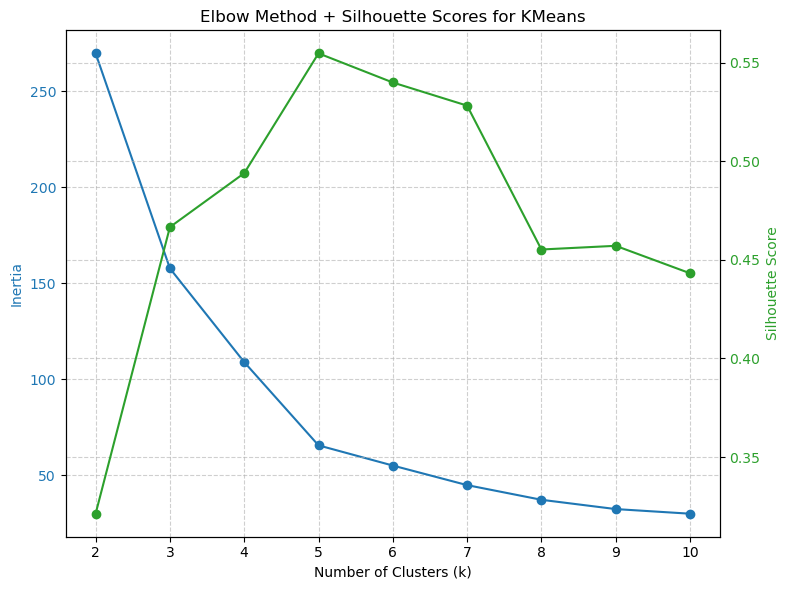

In [26]:

# Range of k values
K_RANGE = range(2, 11)

inertias = []
silhouettes = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)
    labels = km.fit_predict(scaled_x)
    
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(scaled_x, labels))

# Plot elbow + silhouette
fig, ax1 = plt.subplots(figsize=(8,6))

color1 = 'tab:blue'
ax1.set_xlabel("Number of Clusters (k)")
ax1.set_ylabel("Inertia", color=color1)
ax1.plot(K_RANGE, inertias, marker='o', color=color1, label="Inertia")
ax1.tick_params(axis='y', labelcolor=color1)
ax1.grid(True, linestyle='--', alpha=0.6)   # add grid

ax2 = ax1.twinx()  # second axis for silhouette
color2 = 'tab:green'
ax2.set_ylabel("Silhouette Score", color=color2)
ax2.plot(K_RANGE, silhouettes, marker='o', color=color2, label="Silhouette")
ax2.tick_params(axis='y', labelcolor=color2)
ax2.grid(True, linestyle='--', alpha=0.6)   # add grid

plt.title("Elbow Method + Silhouette Scores for KMeans")
fig.tight_layout()
plt.show()

### We can see that our optimal K is 5 from the cross plot

c:\Users\Tammy\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Tammy\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Tammy\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Tammy\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Window

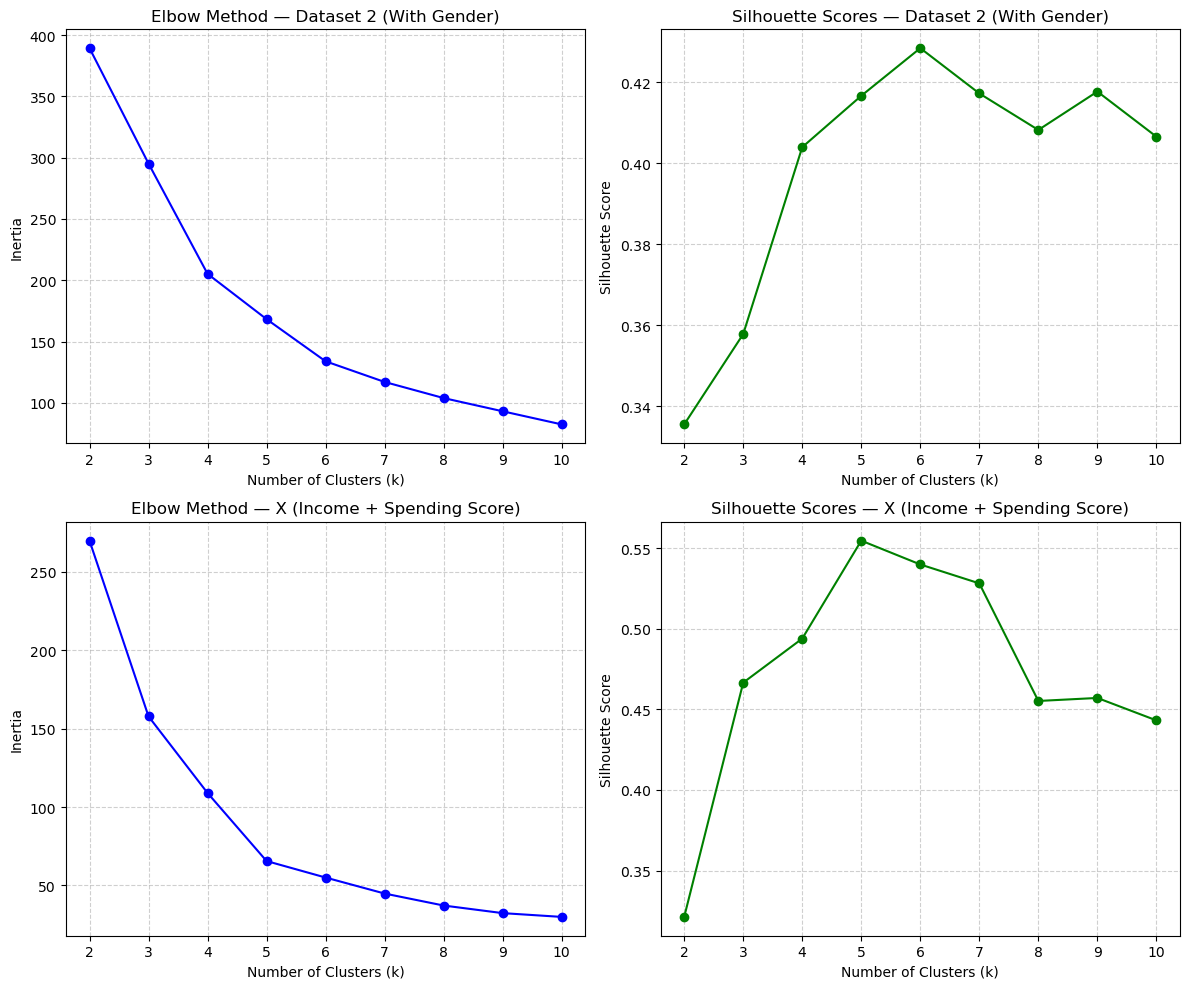

In [27]:
# Dataset 2 (with Gender, already scaled)
X2_scaled = df_2_scaled  

# X (Income + Spending Score only)
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

datasets = [X2_scaled, X_scaled]
titles   = ["Dataset 2 (With Gender)", "X (Income + Spending Score)"]

K_RANGE = range(2, 11)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for idx, (X_scaled, title) in enumerate(zip(datasets, titles)):
    inertias = []
    silhouettes = []

    for k in K_RANGE:
        km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)
        labels = km.fit_predict(X_scaled)
        inertias.append(km.inertia_)
        silhouettes.append(silhouette_score(X_scaled, labels))

    # Elbow plot
    axes[idx, 0].plot(K_RANGE, inertias, marker='o', color='blue')
    axes[idx, 0].set_title(f"Elbow Method — {title}")
    axes[idx, 0].set_xlabel("Number of Clusters (k)")
    axes[idx, 0].set_ylabel("Inertia")
    axes[idx, 0].grid(True, linestyle='--', alpha=0.6)

    # Silhouette plot
    axes[idx, 1].plot(K_RANGE, silhouettes, marker='o', color='green')
    axes[idx, 1].set_title(f"Silhouette Scores — {title}")
    axes[idx, 1].set_xlabel("Number of Clusters (k)")
    axes[idx, 1].set_ylabel("Silhouette Score")
    axes[idx, 1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### Despite having different inertia values, we can see that the K for both model follow the same trend hence, we will apply K=5 for our PCA 

c:\Users\Tammy\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


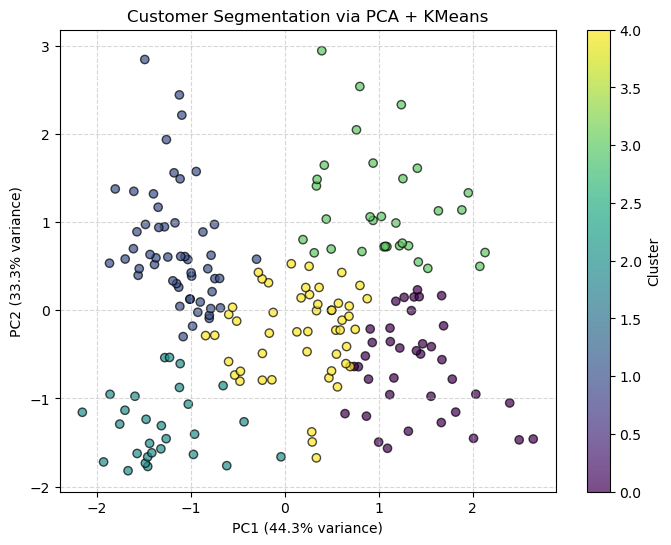

In [28]:
# Run PCA with 2 components for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(df_2_scaled)

# Apply KMeans clustering (choose k=5 for different classes of spenders spenders)
kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(X_pca)


# Plot PCA1 vs PCA2 with clusters
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters, cmap='viridis', alpha=0.7, edgecolor='k')
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.title("Customer Segmentation via PCA + KMeans")
plt.colorbar(label="Cluster")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


In [34]:

cluster_labels = kmeans.labels_
print("Cluster labels for each point is :" + str(cluster_labels))

Cluster labels for each point is :[2 2 4 2 2 2 0 2 0 2 0 2 0 2 0 2 4 2 0 2 4 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0
 2 4 2 0 2 0 2 0 2 4 4 4 4 4 4 4 0 0 4 4 0 4 0 0 2 0 4 0 2 4 0 2 4 0 4 0 0
 0 4 4 4 4 4 0 4 0 4 1 4 4 1 4 4 0 1 4 4 4 1 4 4 4 1 4 4 0 1 4 1 0 4 0 0 0
 1 4 1 1 1 0 4 4 4 1 4 4 1 4 1 4 1 3 1 3 1 4 1 4 1 3 1 4 1 3 1 1 1 3 1 3 1
 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3
 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1]


### Adding cluster labels to original dataframe Customer_Segmentation

In [36]:
df_1['Customer_Segment'] = cluster_labels
df_1.head()

,Age,Annual Income (k$),Spending Score (1-100),Gender_Female,Gender_Male,Customer_Segment
0,19,15,39,0,1,2
1,21,15,81,0,1,2
2,20,16,6,1,0,4
3,23,16,77,1,0,2
4,31,17,40,1,0,2


### Customer Classification according to cluster

In [40]:

# Calculate the average income and spending score for each cluster
cluster_summary = df_1.groupby('Customer_Segment')[['Annual Income (k$)', 'Spending Score (1-100)']].mean()
print("Cluster Averages:\n", cluster_summary)

# Sorting by Annual Income ascending
sorted_clusters = cluster_summary.sort_values(by='Annual Income (k$)').index.tolist()

Cluster Averages:
                   Annual Income (k$)  Spending Score (1-100)
Customer_Segment                                            
0                          41.815789               35.605263
1                          80.576923               74.000000
2                          27.821429               73.535714
3                          89.687500               17.343750
4                          53.680000               44.500000


### From the above results, we have 5 different outcomes that can shape how we segment our customers
#### 1. Cluster 0 customers are moderate income earners and spend moderately
#### 2. Cluster 1 customers are high income earners and spend highly
#### 3. Cluster 2 customers are low income earners but spend highly
#### 4. cluster 3 customes are the top earners but spend very low
#### 5. cluster 4 customers are average earners and spend averagely 

In [41]:
df_1.drop(columns=['Spending_Group'], inplace=True)

In [42]:
df_1.head()

,Age,Annual Income (k$),Spending Score (1-100),Gender_Female,Gender_Male,Customer_Segment
0,19,15,39,0,1,2
1,21,15,81,0,1,2
2,20,16,6,1,0,4
3,23,16,77,1,0,2
4,31,17,40,1,0,2


In [43]:
label_mapping = {
    sorted_clusters[0]: "Moderate",
    sorted_clusters[1]: "Affluent",
    sorted_clusters[2]: "Aspirational",
    sorted_clusters[3]: "Prudent",
    sorted_clusters[4]: "Average"
}

# 5. Apply the rule to create a new descriptive column
df['Spending_Group'] = df['Customer_Segment'].map(label_mapping)

In [44]:
df_1.head()

,Age,Annual Income (k$),Spending Score (1-100),Gender_Female,Gender_Male,Customer_Segment
0,19,15,39,0,1,2
1,21,15,81,0,1,2
2,20,16,6,1,0,4
3,23,16,77,1,0,2
4,31,17,40,1,0,2


### I will apply same method to the X data with just annual income and spending score

In [46]:
X['Customer_Segment'] = cluster_labels
X.head()

C:\Users\Tammy\AppData\Local\Temp\ipykernel_37564\539640940.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Customer_Segment'] = cluster_labels


,Annual Income (k$),Spending Score (1-100),Customer_Segment
0,15,39,2
1,15,81,2
2,16,6,4
3,16,77,2
4,17,40,2


In [48]:
cluster_summary_1 = X.groupby('Customer_Segment')[['Annual Income (k$)', 'Spending Score (1-100)']].mean()
print("Cluster Averages:\n", cluster_summary_1)

print("Cluster Averages:\n", cluster_summary)

Cluster Averages:
                   Annual Income (k$)  Spending Score (1-100)
Customer_Segment                                            
0                          41.815789               35.605263
1                          80.576923               74.000000
2                          27.821429               73.535714
3                          89.687500               17.343750
4                          53.680000               44.500000
Cluster Averages:
                   Annual Income (k$)  Spending Score (1-100)
Customer_Segment                                            
0                          41.815789               35.605263
1                          80.576923               74.000000
2                          27.821429               73.535714
3                          89.687500               17.343750
4                          53.680000               44.500000


In [58]:
X.to_csv("customers_clustered_tam.csv", index=False)

### From the results from this work, it can be clearly seen that for unsupervised learning, with high number of features, PCA can work perfectly for feature selection